In [19]:
# --- Assignment 2: Model Evaluation (Jupyter Notebook Version) ---

import os
import torch
import numpy as np
from PIL import Image
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score
import matplotlib.pyplot as plt
from tqdm import tqdm
from dataset import RSSegmentationDataset
import segmentation_models_pytorch as smp
import seaborn as sns
import pandas as pd

In [20]:
# Function to predict and accumulate all test labels and predictions
def predict_full_image(model, dataset, device):
    model.eval()
    predictions = []
    ground_truths = []

    with torch.no_grad():
        for image, label in tqdm(dataset, desc="Predicting"):
            image = image.unsqueeze(0).to(device)
            output = model(image)
            pred = output.argmax(dim=1).squeeze().cpu().numpy()
            gt = label.numpy()

            predictions.append(pred.flatten())
            ground_truths.append(gt.flatten())

    pred_all = np.concatenate(predictions)
    gt_all = np.concatenate(ground_truths)
    return gt_all, pred_all

# Evaluation metrics

def evaluate_metrics(gt, pred, num_classes):
    acc = accuracy_score(gt, pred)
    precision = precision_score(gt, pred, average=None, labels=range(num_classes), zero_division=0)
    recall = recall_score(gt, pred, average=None, labels=range(num_classes), zero_division=0)
    f1 = f1_score(gt, pred, average=None, labels=range(num_classes), zero_division=0)
    cm = confusion_matrix(gt, pred, labels=range(num_classes))
    return acc, precision, recall, f1, cm

# Visualization of predictions
def visualize_prediction(image_tensor, label, pred, color_map):
    image_np = image_tensor.permute(1, 2, 0).numpy()
    image_np = (image_np * 255).astype(np.uint8)

    def colorize(mask):
        h, w = mask.shape
        color_mask = np.zeros((h, w, 3), dtype=np.uint8)
        for rgb, cls in color_map.items():
            color_mask[mask == cls] = rgb
        return color_mask

    fig, axs = plt.subplots(1, 3, figsize=(18, 6))
    axs[0].imshow(image_np)
    axs[0].set_title("Input Image")
    axs[1].imshow(colorize(label.numpy()))
    axs[1].set_title("Ground Truth")
    axs[2].imshow(colorize(pred))
    axs[2].set_title("Prediction")

    for ax in axs:
        ax.axis('off')
    plt.tight_layout()
    plt.show()

# Evaluation runner for one model
def run_evaluation(use_dsm=False):
    config_path = "data/data-config.json"
    image_dir = "data/mspectral-images"
    label_dir = "data/labels"
    dsm_dir = "data/ndsm-images" if use_dsm else None
    model_path = f"output/unet_resnet18_{'rgbd' if use_dsm else 'rgb'}.pth"

    dataset = RSSegmentationDataset(
        image_dir=image_dir,
        label_dir=label_dir,
        dsm_dir=dsm_dir,
        config_path=config_path,
        patch_size=256,
        split="test"
    )

    in_channels = 4 if use_dsm else 3
    num_classes = 6
    device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")

    model = smp.Unet(
        encoder_name="resnet18",
        encoder_weights=None,
        in_channels=in_channels,
        classes=num_classes
    )
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device)

    print(f"\nEvaluating {'4-Channel (RGB+DSM)' if use_dsm else '3-Channel (RGB)'} Model")
    gt, pred = predict_full_image(model, dataset, device)
    acc, precision, recall, f1, cm = evaluate_metrics(gt, pred, num_classes)

    class_names = ["Impervious", "Building", "Low Veg", "Tree", "Car", "Clutter"]

    df = pd.DataFrame({
        "Class": class_names,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    })
    display(df.round(4))
    print("\nOverall Accuracy:", round(acc, 4))

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("Ground Truth")
    plt.title("Confusion Matrix")
    plt.show()

    # show one prediction
    color_map = { (255,255,255):0, (0,0,255):1, (0,255,255):2, (0,255,0):3, (255,255,0):4, (255,0,0):5 }
    image, label = dataset[0]
    model.eval()
    with torch.no_grad():
        pred = model(image.unsqueeze(0).to(device)).argmax(dim=1).squeeze().cpu().numpy()
    visualize_prediction(image, label, pred, color_map)

/var/folders/6r/lw1cp6x117zfdkxgl862fymc0000gn/T/ipykernel_92726/3547122700.py:83: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path,


Evaluating 3-Channel (RGB) Model














































































Predicting: 100%|██████████| 325/325 [00:04<00:00, 80.88it/s]


,Class,Precision,Recall,F1-Score
0,Impervious,0.8581,0.8514,0.8547
1,Building,0.9039,0.9013,0.9026
2,Low Veg,0.7517,0.6782,0.7130
3,Tree,0.7973,0.8834,0.8381
4,Car,0.7798,0.5926,0.6734
5,Clutter,0.0000,0.0000,0.0000



Overall Accuracy: 0.8298


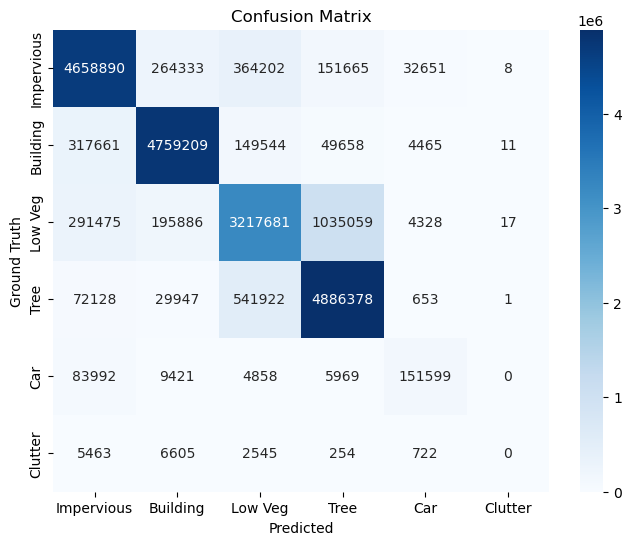

Exception ignored in: <function tqdm.__del__ at 0x12afa0280>
Traceback (most recent call last):
  File "/opt/anaconda3/envs/geo/lib/python3.10/site-packages/tqdm/std.py", line 1148, in __del__
    self.close()
  File "/opt/anaconda3/envs/geo/lib/python3.10/site-packages/tqdm/notebook.py", line 279, in close
    self.disp(bar_style='danger', check_delay=False)
AttributeError: 'tqdm_notebook' object has no attribute 'disp'
Exception ignored in: <function tqdm.__del__ at 0x12afa0280>
Traceback (most recent call last):
  File "/opt/anaconda3/envs/geo/lib/python3.10/site-packages/tqdm/std.py", line 1148, in __del__
    self.close()
  File "/opt/anaconda3/envs/geo/lib/python3.10/site-packages/tqdm/notebook.py", line 279, in close
    self.disp(bar_style='danger', check_delay=False)
AttributeError: 'tqdm_notebook' object has no attribute 'disp'


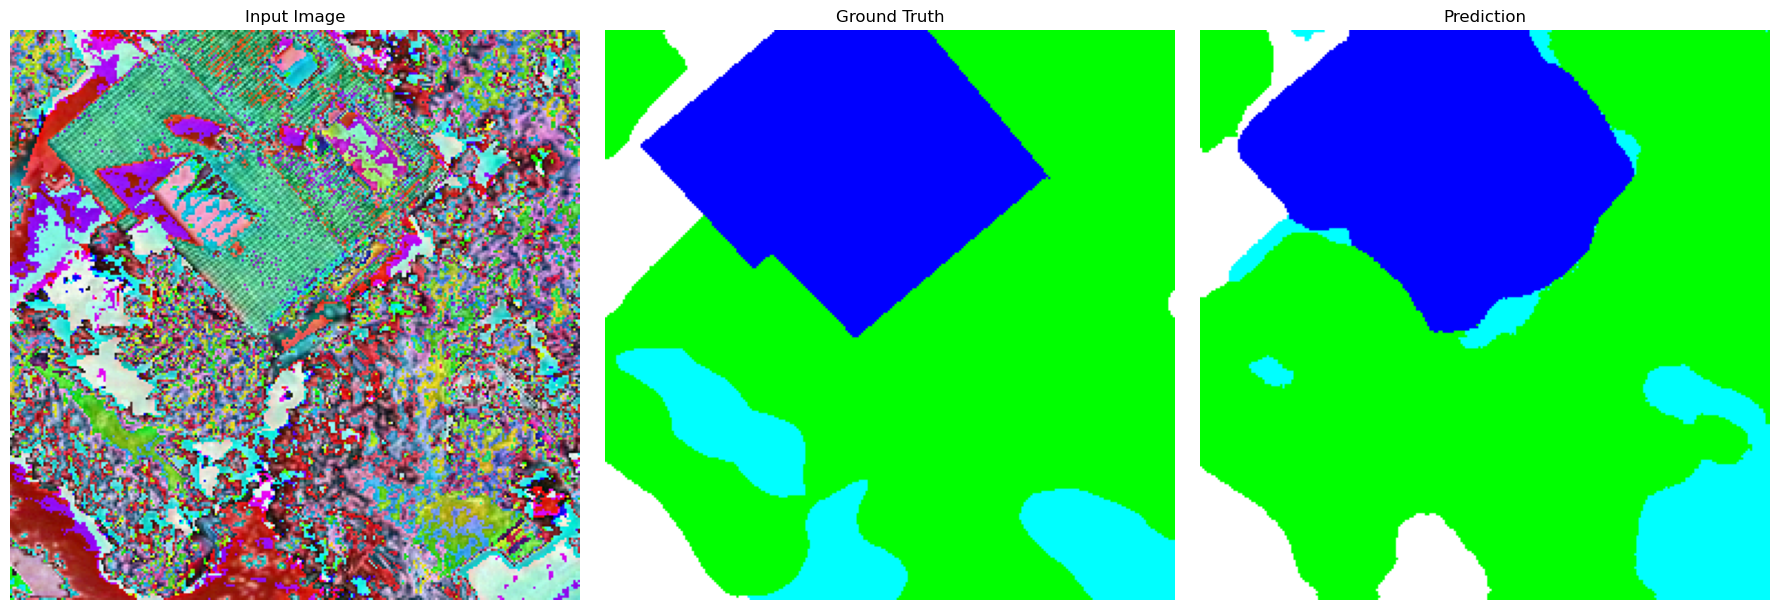

In [21]:
# Call both evaluations (can be split across cells in a real notebook)
run_evaluation(use_dsm=False)

/var/folders/6r/lw1cp6x117zfdkxgl862fymc0000gn/T/ipykernel_92726/3547122700.py:83: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path,


Evaluating 4-Channel (RGB+DSM) Model


Predicting: 100%|██████████| 325/325 [00:04<00:00, 79.36it/s]


,Class,Precision,Recall,F1-Score
0,Impervious,0.8825,0.8450,0.8633
1,Building,0.9226,0.9164,0.9195
2,Low Veg,0.7216,0.7207,0.7212
3,Tree,0.8149,0.8606,0.8371
4,Car,0.7444,0.6685,0.7044
5,Clutter,0.4675,0.1760,0.2557



Overall Accuracy: 0.8364


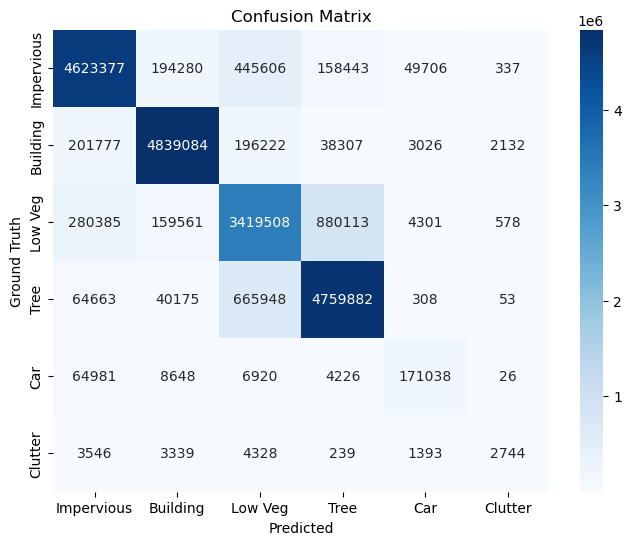

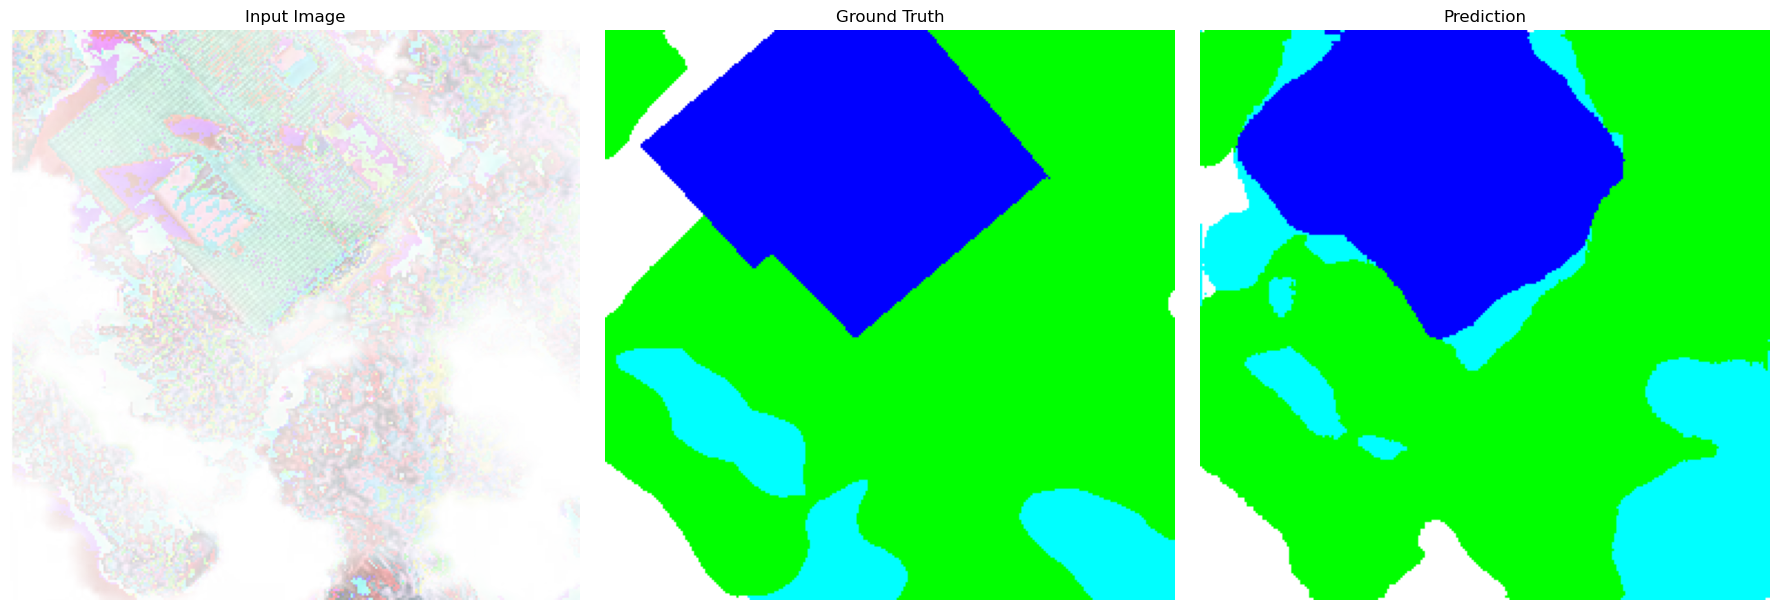

In [22]:
run_evaluation(use_dsm=True)